# Stage 4: Confidence and Uncertainty Analysis

The previous stages showed that the model behaves differently when evaluated outside its original training distribution.

Stage 1 showed that a controlled reduction in image contrast affected both classification performance and calibration.

Stage 2 then evaluated the same trained model on the external RSNA chest X-ray dataset without retraining it.

Stage 3 showed that temperature scaling improved the model's probability estimates on the external dataset, but substantial calibration error remained.

In this stage, I want to look more closely at the model's confidence.

The main question is:

**When the model is confident, is it usually correct?**

I will examine the relationship between confidence and correctness, identify highly confident incorrect predictions, and compare the original and temperature-scaled probabilities.

This is not a new training experiment. The classifier remains unchanged throughout this analysis.

The uncertainty measure used here is based on the model's predictive probability. It should therefore be interpreted as a confidence-based uncertainty analysis rather than a complete estimate of epistemic uncertainty.

In [1]:
# NumPy is used for numerical calculations and for working
# with the saved prediction arrays.
import numpy as np

# Pandas makes it easier to organise the predictions into
# tables and analyse groups of predictions.
import pandas as pd

# Matplotlib will be used for the confidence and uncertainty plots.
import matplotlib.pyplot as plt

# These metrics allow us to compare the predictions with
# the actual RSNA labels.
from sklearn.metrics import (
    accuracy_score,
    brier_score_loss,
    log_loss,
    roc_auc_score
)

print("Stage 4 imports loaded successfully.")

Stage 4 imports loaded successfully.


In [4]:
# Keep the project location consistent with the previous notebooks.
# This is important because Stage 4 should use exactly the same
# prediction file that was created and validated during Stage 2.

PROJECT_ROOT = (
    r"D:\0001_Kings_AI_Project"
    r"\trustworthy-ai-medical-imaging"
)

# Stage 2 saved the validated RSNA predictions in this file.
prediction_path = (
    PROJECT_ROOT
    + r"\research_data\rsna_stage2_predictions.npz"
)

print("Project root:")
print(PROJECT_ROOT)

print()
print("Stage 2 prediction file:")
print(prediction_path)

Project root:
D:\0001_Kings_AI_Project\trustworthy-ai-medical-imaging

Stage 2 prediction file:
D:\0001_Kings_AI_Project\trustworthy-ai-medical-imaging\research_data\rsna_stage2_predictions.npz


In [6]:
# Load the predictions generated during Stage 2.
#
# We deliberately use the saved prediction file rather than
# running the model again. This keeps Stage 4 independent from
# the original inference process and ensures that we analyse
# exactly the same predictions that were already validated.

stage2_predictions = np.load(prediction_path)


# The Stage 2 file was saved using the keys:
# "logits", "probabilities", and "labels".
#
# We assign them to the longer variable names used throughout
# this notebook so the rest of the analysis remains easy to read.

all_logits = stage2_predictions["logits"]
all_probabilities = stage2_predictions["probabilities"]
all_labels = stage2_predictions["labels"]


print("Stage 2 predictions loaded successfully.")
print("Prediction file:", prediction_path)

print()
print("Number of logits:", len(all_logits))
print("Number of probabilities:", len(all_probabilities))
print("Number of labels:", len(all_labels))

Stage 2 predictions loaded successfully.
Prediction file: D:\0001_Kings_AI_Project\trustworthy-ai-medical-imaging\research_data\rsna_stage2_predictions.npz

Number of logits: 25684
Number of probabilities: 25684
Number of labels: 25684


In [7]:
# Before starting the analysis, make sure that the three arrays
# contain the same number of predictions.
#
# This is a simple check, but it is important because every
# probability must correspond to exactly one ground-truth label.

assert len(all_logits) == len(all_probabilities)
assert len(all_probabilities) == len(all_labels)


# Check the basic shape and value ranges of the data.

print("Prediction arrays validated.")
print()
print("Number of predictions:", len(all_labels))
print("Logits shape:", all_logits.shape)
print("Probabilities shape:", all_probabilities.shape)
print("Labels shape:", all_labels.shape)

print()
print(
    f"Probability range: "
    f"{all_probabilities.min():.6f} to "
    f"{all_probabilities.max():.6f}"
)

print(
    f"Label values: {np.unique(all_labels)}"
)

Prediction arrays validated.

Number of predictions: 25684
Logits shape: (25684,)
Probabilities shape: (25684,)
Labels shape: (25684,)

Probability range: 0.212479 to 0.974634
Label values: [0 1]


In [8]:
# The model produces a probability for the positive class.
#
# For this analysis, a probability of 0.5 is used as the
# classification threshold, matching the earlier evaluation.
#
# Confidence is slightly different from the positive-class
# probability.
#
# For example:
#   probability = 0.90 -> confidence = 0.90
#   probability = 0.10 -> confidence = 0.90
#
# In both cases the model is highly confident about its prediction.

predicted_labels = (
    all_probabilities >= 0.5
).astype(int)


# Calculate the confidence of each prediction.
#
# We take the probability of whichever class the model predicted.

confidence = np.maximum(
    all_probabilities,
    1 - all_probabilities
)


# Compare the predictions with the actual labels.

correct_predictions = (
    predicted_labels == all_labels
)


print("Prediction and confidence analysis prepared.")
print()
print("Correct predictions:",
      correct_predictions.sum())

print("Incorrect predictions:",
      (~correct_predictions).sum())

print(
    "Overall accuracy:",
    f"{correct_predictions.mean():.4f}"
)

Prediction and confidence analysis prepared.

Correct predictions: 9346
Incorrect predictions: 16338
Overall accuracy: 0.3639


In [9]:
# One of the main questions in this stage is:
#
# Does the model become less confident when it is wrong?
#
# A useful confidence measure should generally be higher for
# correct predictions and lower for incorrect predictions.
#
# We therefore compare the confidence distributions of both groups.

correct_confidence = confidence[
    correct_predictions
]

incorrect_confidence = confidence[
    ~correct_predictions
]


print("Confidence comparison")
print("---------------------")

print(
    f"Correct predictions   : "
    f"n = {len(correct_confidence):,} | "
    f"mean = {correct_confidence.mean():.4f} | "
    f"median = {np.median(correct_confidence):.4f}"
)

print(
    f"Incorrect predictions : "
    f"n = {len(incorrect_confidence):,} | "
    f"mean = {incorrect_confidence.mean():.4f} | "
    f"median = {np.median(incorrect_confidence):.4f}"
)

Confidence comparison
---------------------
Correct predictions   : n = 9,346 | mean = 0.6384 | median = 0.6041
Incorrect predictions : n = 16,338 | mean = 0.6817 | median = 0.6588


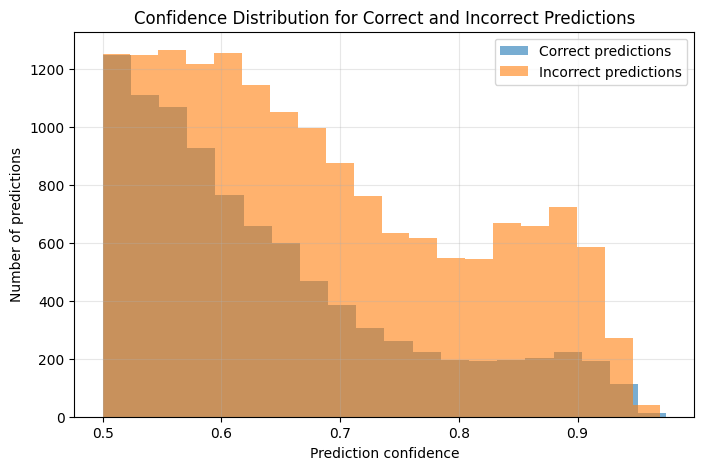

In [10]:
# A histogram makes the previous comparison easier to interpret.
#
# We are looking for separation between correct and incorrect
# predictions.
#
# If incorrect predictions are also concentrated at very high
# confidence, that would be important because it means the model
# can be confidently wrong.

plt.figure(figsize=(8, 5))

plt.hist(
    correct_confidence,
    bins=20,
    alpha=0.6,
    label="Correct predictions"
)

plt.hist(
    incorrect_confidence,
    bins=20,
    alpha=0.6,
    label="Incorrect predictions"
)

plt.xlabel("Prediction confidence")
plt.ylabel("Number of predictions")

plt.title(
    "Confidence Distribution for Correct and Incorrect Predictions"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [11]:
# A particularly important case is a prediction that is wrong
# but has very high confidence.
#
# These examples are more concerning than uncertain mistakes
# because a user could incorrectly trust the prediction.
#
# We use 0.90 as a simple threshold for this analysis.

HIGH_CONFIDENCE_THRESHOLD = 0.90


high_confidence_errors = (
    (~correct_predictions)
    & (confidence >= HIGH_CONFIDENCE_THRESHOLD)
)


print("High-confidence error analysis")
print("------------------------------")

print(
    f"Confidence threshold: "
    f"{HIGH_CONFIDENCE_THRESHOLD:.2f}"
)

print(
    f"High-confidence errors: "
    f"{high_confidence_errors.sum():,}"
)

print(
    f"Percentage of all predictions: "
    f"{high_confidence_errors.mean() * 100:.2f}%"
)

High-confidence error analysis
------------------------------
Confidence threshold: 0.90
High-confidence errors: 874
Percentage of all predictions: 3.40%


In [12]:
# Sort the incorrect predictions by confidence.
#
# This gives us a small set of the strongest examples where
# the model was wrong despite being highly confident.

error_indices = np.where(
    ~correct_predictions
)[0]


# Sort the error indices from highest confidence to lowest.

sorted_error_indices = error_indices[
    np.argsort(
        confidence[error_indices]
    )[::-1]
]


# Display the 20 most confident errors.

top_n = min(
    20,
    len(sorted_error_indices)
)


print(
    f"Top {top_n} most confident incorrect predictions"
)
print("-----------------------------------------------")

print(
    f"{'Index':>8}"
    f"{'Actual':>10}"
    f"{'Predicted':>12}"
    f"{'Probability':>15}"
    f"{'Confidence':>14}"
)

print("-" * 61)


for index in sorted_error_indices[:top_n]:

    print(
        f"{index:>8}"
        f"{int(all_labels[index]):>10}"
        f"{int(predicted_labels[index]):>12}"
        f"{all_probabilities[index]:>15.4f}"
        f"{confidence[index]:>14.4f}"
    )

Top 20 most confident incorrect predictions
-----------------------------------------------
   Index    Actual   Predicted    Probability    Confidence
-------------------------------------------------------------
   13939         0           1         0.9698        0.9698
   24715         0           1         0.9662        0.9662
    7456         0           1         0.9609        0.9609
     111         0           1         0.9590        0.9590
    3113         0           1         0.9583        0.9583
   11803         0           1         0.9575        0.9575
    3580         0           1         0.9570        0.9570
   18140         0           1         0.9568        0.9568
   14899         0           1         0.9566        0.9566
   22385         0           1         0.9560        0.9560
   16669         0           1         0.9555        0.9555
   18264         0           1         0.9547        0.9547
   17018         0           1         0.9546        0.9546
   246

In [19]:
# Instead of looking only at individual predictions, we can
# group predictions into confidence ranges.
#
# For each confidence range we will calculate:
#
#   1. Number of predictions
#   2. Average confidence
#   3. Observed accuracy
#
# If confidence is well aligned with actual performance,
# average confidence and observed accuracy should be reasonably
# close to each other.

confidence_bins = np.linspace(
    0.5,
    1.0,
    11
)


confidence_bin_results = []


for lower, upper in zip(
    confidence_bins[:-1],
    confidence_bins[1:]
):

    # Include the upper boundary only for the final bin.
    if upper == 1.0:

        mask = (
            (confidence >= lower)
            & (confidence <= upper)
        )

    else:

        mask = (
            (confidence >= lower)
            & (confidence < upper)
        )


    count = mask.sum()


    # Skip empty bins so that we do not calculate statistics
    # from zero observations.

    if count == 0:
        continue


    average_confidence = confidence[mask].mean()
    observed_accuracy = correct_predictions[mask].mean()


    confidence_bin_results.append(
        {
            "confidence_range":
                f"{lower:.2f}-{upper:.2f}",

            "count":
                count,

            "average_confidence":
                average_confidence,

            "observed_accuracy":
                observed_accuracy
        }
    )


confidence_bins_df = pd.DataFrame(
    confidence_bin_results
)


confidence_bins_df

,confidence_range,count,average_confidence,observed_accuracy
0,0.50-0.55,5145,0.524466,0.482993
1,0.55-0.60,4698,0.574469,0.434014
2,0.60-0.65,3960,0.624241,0.371212
3,0.65-0.70,3093,0.674154,0.326867
4,0.70-0.75,2228,0.723291,0.297127
5,0.75-0.80,1742,0.773871,0.273249
6,0.80-0.85,1664,0.825996,0.238582
7,0.85-0.90,1929,0.875372,0.235874
8,0.90-0.95,1190,0.919051,0.284034
9,0.95-1.00,35,0.956095,0.371429


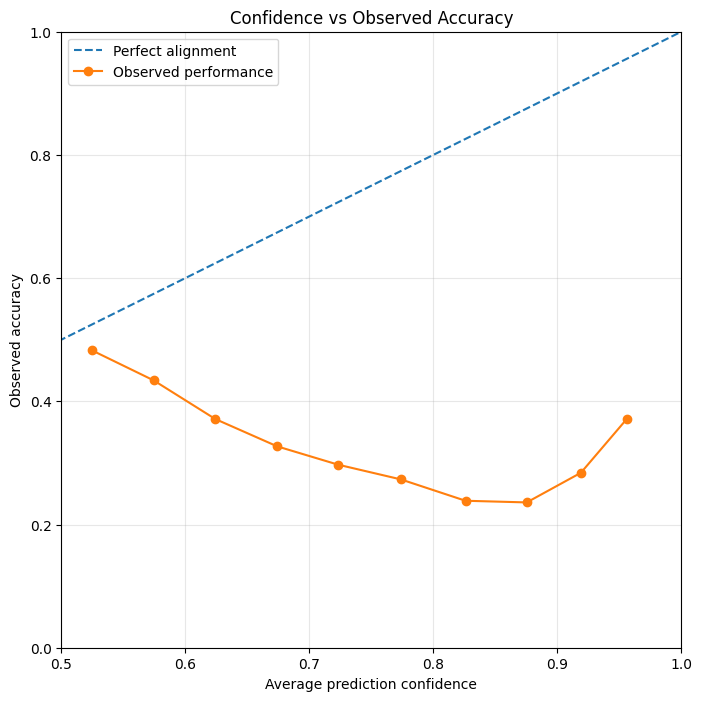

In [20]:
# This plot provides a simple reliability-style view of the
# model's confidence.
#
# The diagonal line represents the ideal situation where
# confidence and observed accuracy are equal.
#
# For example, if a group has an average confidence of 0.90
# and an observed accuracy of 0.60, the model is substantially
# more confident than its actual performance justifies.

plt.figure(figsize=(8, 8))

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect alignment"
)


plt.plot(
    confidence_bins_df["average_confidence"],
    confidence_bins_df["observed_accuracy"],
    marker="o",
    label="Observed performance"
)


plt.xlabel("Average prediction confidence")
plt.ylabel("Observed accuracy")

plt.title(
    "Confidence vs Observed Accuracy"
)

plt.xlim(0.5, 1.0)
plt.ylim(0.0, 1.0)

plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [21]:
# Stage 3 showed that temperature scaling improved the quality
# of the probability estimates on the external RSNA evaluation.
#
# The learned temperature from the verified Stage 3 run was:
#
#     T = 2.0350
#
# We do not learn a new temperature here.
# We simply apply the previously learned value to the same
# Stage 2 logits.
#
# This keeps Stage 4 consistent with the Stage 3 experiment.

LEARNED_TEMPERATURE = 2.0350


# Divide the original logits by the learned temperature.

calibrated_logits = (
    all_logits / LEARNED_TEMPERATURE
)


# Convert the calibrated logits back into probabilities.

calibrated_probabilities = (
    1
    /
    (
        1
        + np.exp(-calibrated_logits)
    )
)


print("Stage 3 temperature applied.")
print(
    f"Temperature: {LEARNED_TEMPERATURE:.4f}"
)

print(
    f"Original probability range: "
    f"{all_probabilities.min():.6f} to "
    f"{all_probabilities.max():.6f}"
)

print(
    f"Calibrated probability range: "
    f"{calibrated_probabilities.min():.6f} to "
    f"{calibrated_probabilities.max():.6f}"
)

Stage 3 temperature applied.
Temperature: 2.0350
Original probability range: 0.212479 to 0.974634
Calibrated probability range: 0.344398 to 0.857289


In [22]:
# Temperature scaling changes the probabilities but does not
# change the underlying ranking of the predictions.
#
# Here we compare the confidence before and after calibration.
#
# Because the learned temperature is greater than 1, the model's
# probabilities should generally move closer towards 0.5.
#
# This means the model should become less confident overall.

calibrated_confidence = np.maximum(
    calibrated_probabilities,
    1 - calibrated_probabilities
)


print("Confidence before vs after temperature scaling")
print("-----------------------------------------------")

print(
    f"Mean confidence before: "
    f"{confidence.mean():.4f}"
)

print(
    f"Mean confidence after : "
    f"{calibrated_confidence.mean():.4f}"
)

print()

print(
    f"Median confidence before: "
    f"{np.median(confidence):.4f}"
)

print(
    f"Median confidence after : "
    f"{np.median(calibrated_confidence):.4f}"
)

Confidence before vs after temperature scaling
-----------------------------------------------
Mean confidence before: 0.6659
Mean confidence after : 0.5909

Median confidence before: 0.6369
Median confidence after : 0.5686


In [23]:
# We now repeat the high-confidence error check after
# temperature scaling.
#
# This is useful because Stage 3 showed improved probability
# quality. We want to see whether that improvement also reduces
# the number of predictions that appear extremely confident.

calibrated_high_confidence_errors = (
    (~correct_predictions)
    & (
        calibrated_confidence
        >= HIGH_CONFIDENCE_THRESHOLD
    )
)


print("High-confidence errors")
print("----------------------")

print(
    f"Before calibration: "
    f"{high_confidence_errors.sum():,}"
)

print(
    f"After calibration : "
    f"{calibrated_high_confidence_errors.sum():,}"
)

print()

print(
    f"Before calibration: "
    f"{high_confidence_errors.mean() * 100:.2f}% "
    f"of all predictions"
)

print(
    f"After calibration : "
    f"{calibrated_high_confidence_errors.mean() * 100:.2f}% "
    f"of all predictions"
)

High-confidence errors
----------------------
Before calibration: 874
After calibration : 0

Before calibration: 3.40% of all predictions
After calibration : 0.00% of all predictions


In [24]:
# Stage 3 already established the main calibration results.
#
# We reproduce the metrics here directly from the Stage 2
# predictions so that Stage 4 has a compact summary of the
# probability-quality changes.
#
# Brier score and log loss evaluate the quality of the
# predicted probabilities.
#
# AUROC is included as a discrimination metric. It should remain
# essentially unchanged because temperature scaling changes the
# confidence values, not the ordering of the predictions.

from sklearn.metrics import (
    brier_score_loss,
    log_loss,
    roc_auc_score
)


brier_before = brier_score_loss(
    all_labels,
    all_probabilities
)

brier_after = brier_score_loss(
    all_labels,
    calibrated_probabilities
)


logloss_before = log_loss(
    all_labels,
    all_probabilities
)

logloss_after = log_loss(
    all_labels,
    calibrated_probabilities
)


auroc_before = roc_auc_score(
    all_labels,
    all_probabilities
)

auroc_after = roc_auc_score(
    all_labels,
    calibrated_probabilities
)


print("Probability quality summary")
print("---------------------------")

print(
    f"Brier Score : "
    f"{brier_before:.4f} -> "
    f"{brier_after:.4f}"
)

print(
    f"Log Loss    : "
    f"{logloss_before:.4f} -> "
    f"{logloss_after:.4f}"
)

print(
    f"AUROC       : "
    f"{auroc_before:.4f} -> "
    f"{auroc_after:.4f}"
)

Probability quality summary
---------------------------
Brier Score : 0.3579 -> 0.3003
Log Loss    : 0.9652 -> 0.8003
AUROC       : 0.5640 -> 0.5640


## Stage 4 Interpretation

This stage examined the model's predictive confidence on the external RSNA evaluation set.

The analysis focused on three questions:

1. Are correct predictions generally associated with higher confidence?
2. How often is the model highly confident but incorrect?
3. Does temperature scaling reduce excessive confidence?

The results showed an important finding: **incorrect predictions were, on average, more confident than correct predictions**. The mean confidence was 0.6817 for incorrect predictions compared with 0.6384 for correct predictions.

The model also produced 874 incorrect predictions with confidence of at least 0.90. The most confident incorrect prediction had a confidence of approximately 0.97. This indicates substantial overconfidence under the external evaluation conditions.

The confidence analysis is based on the model's predicted probabilities. It should therefore be interpreted as a study of **predictive confidence**, rather than a complete measure of model uncertainty.

In particular, this experiment does not separate different sources of uncertainty such as:

- uncertainty caused by limited training data,
- uncertainty caused by model parameters,
- uncertainty caused by distribution shift,
- ambiguity in the medical image itself.

The high-confidence error analysis is particularly relevant to trustworthy artificial intelligence because an incorrect prediction with low confidence is different from an incorrect prediction with very high confidence.

Stage 3 temperature scaling was then applied to the same Stage 2 logits without retraining the model. The learned temperature was **T = 2.0350**.

After temperature scaling, the mean confidence decreased from 0.6659 to 0.5909, while the median confidence decreased from 0.6369 to 0.5686. The Brier score improved from 0.3579 to 0.3003, and log loss improved from 0.9652 to 0.8003.

At the same time, AUROC remained unchanged at 0.5640. This is consistent with the purpose of temperature scaling: it changes the probability values and confidence levels without changing the underlying ranking of the predictions.

The number of predictions above the 0.90 confidence threshold decreased from 874 incorrect predictions to zero after calibration. This should not be interpreted as the errors being eliminated. The calibrated probabilities had a maximum of approximately 0.8573, meaning that no prediction remained in the >=0.90 confidence category.

The external RSNA evaluation should also be interpreted carefully because the model was originally trained on PneumoniaMNIST, while the RSNA study-level labels used here represent **lung opacity**. Therefore, this experiment is an external evaluation of the PneumoniaMNIST-trained model against a related but not identical clinical target.

Overall, Stage 4 shows that the model can be substantially overconfident under external evaluation and that temperature scaling can reduce excessive confidence and improve probability quality without improving the model's underlying discrimination.

However, confidence alone should not be treated as a complete uncertainty estimate. A deterministic model's confidence does not directly measure epistemic uncertainty or distinguish between uncertainty caused by the model, the data, or distribution shift.

Therefore, this stage provides a useful first analysis of confidence behaviour under external shift while motivating the next step: evaluating more explicit uncertainty estimation methods.